In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import quantnado
from quantnado.analysis.core import QuantNadoDataset

In [2]:
OUT_DIR = Path("profiling_output")
SAMPLES_DIR = OUT_DIR / "samples"
GTF_FILE = "local/gencode.v49.annotation.gtf"

### Profiling stats

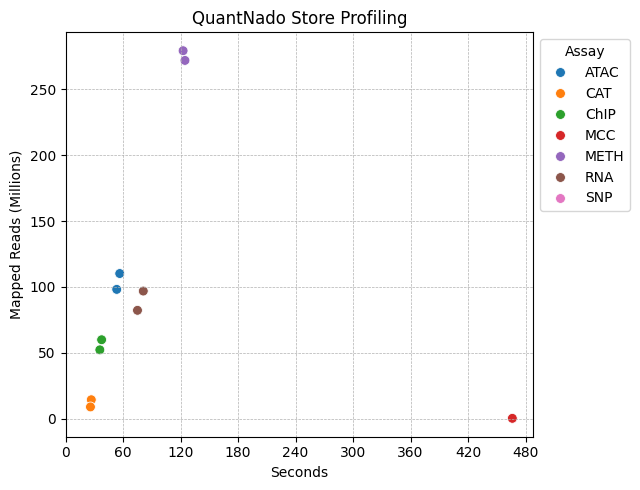

In [3]:
log_files = sorted(OUT_DIR.glob("profile_store_*.log"))

profile_df = []
for log_file in log_files:
    record = {"profile": log_file.stem.replace("profile_store_", "")}
    with open(log_file) as f:
        for line in f:
            if m := re.search(r"in (\d+\.\d+) seconds", line):
                record["seconds"] = float(m.group(1))
            if m := re.search(r"([\d,]+) mapped reads", line):
                record["mapped_reads"] = float(m.group(1).replace(",", ""))
            if m := re.search(r"([\d,]+) variants", line):
                record["variants"] = float(m.group(1).replace(",", ""))
            if m := re.search(r"Peak memory: (\d+\.\d+) GB", line):
                record["peak_memory"] = float(m.group(1))
    # if len(record) == 4:  # all fields found
        profile_df.append(record)

profile_df = pd.DataFrame(profile_df)
profile_df["assay"] = profile_df["profile"].apply(lambda x: x.split("-")[0]).replace({"CM": "ChIP", "TAPS": "METH", "gDNA": "SNP"})
profile_df["mapped_reads"] /= 1e6
profile_df.sort_values("assay", inplace=True)

plt.figure(figsize=(6.5, 5))
sns.scatterplot(data=profile_df, x="seconds", y="mapped_reads", hue="assay", s=50)
plt.xlabel("Seconds")
plt.ylabel("Mapped Reads (Millions)")
plt.title("QuantNado Store Profiling")
plt.xticks(range(0, int(max(profile_df["seconds"]) + 60), 60))
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend(title="Assay", loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### Make datasets

In [4]:
md_path = Path(OUT_DIR) / "quantnado_metadata.csv"

if md_path.exists():
    print(f"Metadata file exists: {md_path}")
    metadata = pd.read_csv(md_path)
else:
    metadata = (
        quantnado.metadata_from_seqnado("/Users/catherine/work/datasets", output_dir=OUT_DIR)
        .sort_values("sample_id")
        .groupby("assay")
        .head(2)
        .reset_index(drop=True)
    )

    mcc_row = pd.DataFrame(
        [
            {
                "assay": "MCC",
                "sample_id": "MCC-OCI-AML3",
                "bam_path": "tests/data/OCI-AML3-control-1-1-A_subsample.bam",
            }
        ]
    ).reindex(columns=metadata.columns)

    metadata = pd.concat([metadata, mcc_row], ignore_index=True)
    metadata.to_csv(md_path, index=False)

metadata

Metadata file exists: profiling_output/quantnado_metadata.csv


,assay,sample_id,ip,bam_path,stranded,methylation_path,variant_path
0,ATAC,ATAC-SEM-1,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
1,ATAC,ATAC-SEM-2,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
2,CUT&TAG,CAT-HSC_H3K27ac,H3K27ac,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
3,CUT&TAG,CAT-HSC_MLLN,MLLN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
4,ChIP,CM-RCHACV-1_MLLN,MLLN,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
5,ChIP,CM-RCHACV-1_Menin,Menin,/Users/catherine/work/datasets/seqnado_output/...,NaN,NaN,NaN
6,RNA,RNA-RCHACV-1,NaN,/Users/catherine/work/datasets/seqnado_output/...,R,NaN,NaN
7,RNA,RNA-RCHACV-2,NaN,/Users/catherine/work/datasets/seqnado_output/...,R,NaN,NaN
8,METH,TAPS-RCHACV,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN
9,METH,TAPS-RS411,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN,/Users/catherine/work/datasets/seqnado_output/...,NaN


In [5]:
for _, row in metadata.iterrows():
    sample = row["sample_id"]
    assay = row["assay"]
    store = Path(SAMPLES_DIR / f"{sample}.zarr")

    if not store.exists():
        print(f"Processing {sample} ({assay})...")
        quantnado.create_dataset(
            sample_id=sample,
            assay=assay,
            output_path=store,
            bam_path=row.get("bam_path"),
            methyl_path=row.get("methylation_path"),
            variants_path=row.get("variant_path"),
            stranded=row.get("stranded", False),
            test=True, 
        )
    else:
        print(f"Store exists: {sample} ({assay})")

Store exists: ATAC-SEM-1 (ATAC)
Store exists: ATAC-SEM-2 (ATAC)
Store exists: CAT-HSC_H3K27ac (CUT&TAG)
Store exists: CAT-HSC_MLLN (CUT&TAG)
Store exists: CM-RCHACV-1_MLLN (ChIP)
Store exists: CM-RCHACV-1_Menin (ChIP)
Store exists: RNA-RCHACV-1 (RNA)
Store exists: RNA-RCHACV-2 (RNA)
Store exists: TAPS-RCHACV (METH)
Store exists: TAPS-RS411 (METH)
Store exists: gDNA-RCHACV (SNP)
Store exists: gDNA-SEM (SNP)
Store exists: MCC-OCI-AML3 (MCC)


### Combine

In [6]:
output_path = OUT_DIR / "dataset.zarr"
if not output_path.exists():
    QuantNadoDataset.combine(src=SAMPLES_DIR, output=output_path)

### Open zarr

In [7]:
qn = QuantNadoDataset(output_path, annotation=GTF_FILE)

2026-04-10 17:21:06.786 | INFO     | quantnado.analysis.core:set_annotation:267 - Loaded annotation: 78,691 genes from local/gencode.v49.annotation.gtf


### Properties

In [8]:
print("Sample names:\n", qn.sample_names)  # list[str]
print("Assays:\n", qn.assays)  # list[str]  — array keys present across stores
print("Chromosomes:\n", qn.chromosomes)  # list[str]  — excludes 'metadata' group
print("Chromsizes:\n", qn.chromsizes)  # dict[str, int]

Sample names:
 ['ATAC-SEM-1', 'ATAC-SEM-2', 'CAT-HSC_H3K27ac', 'CAT-HSC_MLLN', 'CM-RCHACV-1_MLLN', 'CM-RCHACV-1_Menin', 'MCC-OCI-AML3_ABCA2', 'MCC-OCI-AML3_ARID1B', 'MCC-OCI-AML3_ASAP2', 'MCC-OCI-AML3_ASXL1', 'MCC-OCI-AML3_BCL11A', 'MCC-OCI-AML3_BCL2', 'MCC-OCI-AML3_BRD4', 'MCC-OCI-AML3_CASP2', 'MCC-OCI-AML3_CD38', 'MCC-OCI-AML3_CDC25A', 'MCC-OCI-AML3_CDK6', 'MCC-OCI-AML3_CXCR4', 'MCC-OCI-AML3_DNMT3A', 'MCC-OCI-AML3_E2F1', 'MCC-OCI-AML3_ERG', 'MCC-OCI-AML3_EXO1', 'MCC-OCI-AML3_EZH2', 'MCC-OCI-AML3_FLT3', 'MCC-OCI-AML3_FOS', 'MCC-OCI-AML3_GFI1', 'MCC-OCI-AML3_GNAQ', 'MCC-OCI-AML3_HIVEP2', 'MCC-OCI-AML3_IDH1', 'MCC-OCI-AML3_IKZF1', 'MCC-OCI-AML3_JAK2', 'MCC-OCI-AML3_JMJD1C', 'MCC-OCI-AML3_JUN', 'MCC-OCI-AML3_KRAS', 'MCC-OCI-AML3_LMO4', 'MCC-OCI-AML3_MBNL1', 'MCC-OCI-AML3_MCM3', 'MCC-OCI-AML3_MEF2C', 'MCC-OCI-AML3_MEF2D', 'MCC-OCI-AML3_MEIS1', 'MCC-OCI-AML3_MSL3', 'MCC-OCI-AML3_MYC', 'MCC-OCI-AML3_NF1', 'MCC-OCI-AML3_PAX5', 'MCC-OCI-AML3_PROM1', 'MCC-OCI-AML3_PTPN11', 'MCC-OCI-AML3_RUNX1'

### Region slice 

→ xr.Dataset  (1-based coords)

In [9]:
region = qn.sel(chrom="chr21", start=34_785_801, end=35_051_302)
print(region)

<xarray.Dataset> Size: 8GB
Dimensions:           (sample: 61, position: 265502)
Coordinates:
  * sample            (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay             (sample) <U7 2kB 'ATAC' 'ATAC' 'CUT&TAG' ... 'SNP' 'SNP'
  * position          (position) int64 2MB 34785801 34785802 ... 35051302
Data variables: (12/62)
    AF                (sample, position) float32 65MB dask.array<chunksize=(1, 265502), meta=np.ndarray>
    atac              (sample, position) float64 130MB dask.array<chunksize=(1, 265502), meta=np.ndarray>
    cat               (sample, position) float64 130MB dask.array<chunksize=(1, 265502), meta=np.ndarray>
    chip              (sample, position) float64 130MB dask.array<chunksize=(1, 265502), meta=np.ndarray>
    coverage          (sample, position) float32 65MB dask.array<chunksize=(1, 265502), meta=np.ndarray>
    DP                (sample, position) float32 65MB dask.array<chunksize=(1, 265502), meta=np.ndarray>
    ...         

### Standard xarray slicing

In [10]:
region.sel(sample="ATAC-SEM-1")

<xarray.Dataset> Size: 127MB
Dimensions:           (position: 265502)
Coordinates:
  * position          (position) int64 2MB 34785801 34785802 ... 35051302
    sample            <U19 76B 'ATAC-SEM-1'
    assay             <U7 28B 'ATAC'
Data variables: (12/62)
    AF                (position) float32 1MB dask.array<chunksize=(265502,), meta=np.ndarray>
    atac              (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    cat               (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    chip              (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    coverage          (position) float32 1MB dask.array<chunksize=(265502,), meta=np.ndarray>
    DP                (position) float32 1MB dask.array<chunksize=(265502,), meta=np.ndarray>
    ...                ...
    viewpoint_SPI1    (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    viewpoint_TAPT1   (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    viewpoint_TERT    (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    viewpoint_TP53    (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    viewpoint_WT1     (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>
    viewpoint_ZNRF1   (position) float64 2MB dask.array<chunksize=(265502,), meta=np.ndarray>

In [11]:
coverage = region.sel(sample=region.assay != "MCC")

In [12]:
coverage = coverage.sel(position=slice(35_048_000, 35_050_000))

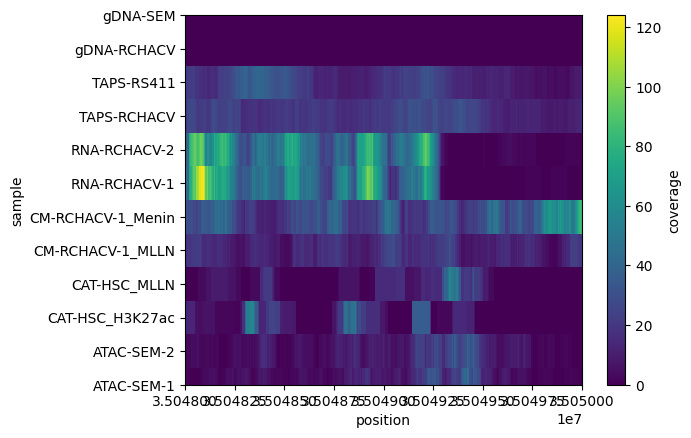

In [13]:
coverage["coverage"].plot()  # x-axis = genomic coords

### Full genome 

→ xr.DataTree  (one node per chromosome)

In [14]:
tree = qn.to_datatree(chromosomes=["chr21"], lazy=True)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       chromsizes:  {'chr1': 248956422, 'chr10': 133797422, 'chr11': 135086622, ...
└── Group: /chr21
        Dimensions:           (sample: 61, position: 46709983)
        Coordinates:
          * sample            (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
            assay             (sample) <U7 2kB 'ATAC' 'ATAC' 'CUT&TAG' ... 'SNP' 'SNP'
          * position          (position) int64 374MB 1 2 3 ... 46709982 46709983
        Data variables: (12/62)
            AF                (sample, position) float32 11GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            atac              (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            cat               (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            chip              (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            coverage          (sample, position) float32 11GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            DP                (sample, position) float32 11GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            ...                ...
            viewpoint_SPI1    (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            viewpoint_TAPT1   (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            viewpoint_TERT    (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            viewpoint_TP53    (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            viewpoint_WT1     (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>
            viewpoint_ZNRF1   (sample, position) float64 23GB dask.array<chunksize=(1, 33554432), meta=np.ndarray>

In [15]:
tree["chr21"].ds.sel(position=slice(1_000_000, 2_000_000))

<xarray.Dataset> Size: 29GB
Dimensions:           (sample: 61, position: 1000001)
Coordinates:
  * sample            (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay             (sample) <U7 2kB 'ATAC' 'ATAC' 'CUT&TAG' ... 'SNP' 'SNP'
  * position          (position) int64 8MB 1000000 1000001 ... 1999999 2000000
Data variables: (12/62)
    AF                (sample, position) float32 244MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    atac              (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    cat               (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    chip              (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    coverage          (sample, position) float32 244MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    DP                (sample, position) float32 244MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    ...                ...
    viewpoint_SPI1    (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    viewpoint_TAPT1   (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    viewpoint_TERT    (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    viewpoint_TP53    (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    viewpoint_WT1     (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>
    viewpoint_ZNRF1   (sample, position) float64 488MB dask.array<chunksize=(1, 1000001), meta=np.ndarray>

---
## Analysis

### Library sizes

Total mapped reads per sample, read from `metadata/total_reads` in each zarr store.

In [16]:
from quantnado.analysis.normalise import get_library_sizes

lib_sizes = get_library_sizes(qn)
lib_sizes

ATAC-SEM-1          110230100.0
ATAC-SEM-2           98190276.0
CAT-HSC_H3K27ac      14380122.0
CAT-HSC_MLLN          8924596.0
CM-RCHACV-1_MLLN     52277976.0
                       ...     
RNA-RCHACV-2         96917722.0
TAPS-RCHACV         279429253.0
TAPS-RS411          272059073.0
gDNA-RCHACV           4272920.0
gDNA-SEM              4882780.0
Name: library_size, Length: 61, dtype: float64

### Normalisation

CPM-normalise a coverage DataArray. Works on any `xr.DataArray`, `xr.Dataset`, or `pd.DataFrame`.

In [17]:
from quantnado.analysis.normalise import normalise

region = qn.sel(chrom="chr21", start=34_785_801, end=35_051_302)

# Normalise ATAC to CPM — library sizes are read automatically from the store
cpm = normalise(region["coverage"], qn,  method="cpm")
cpm

2026-04-10 17:21:33.246 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:548 - Normalised xr.DataArray to CPM.


<xarray.DataArray 'coverage' (sample: 61, position: 265502)> Size: 130MB
dask.array<truediv, shape=(61, 265502), dtype=float64, chunksize=(1, 265502), chunktype=numpy.ndarray>
Coordinates:
  * sample    (sample) <U19 5kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay     (sample) <U7 2kB 'ATAC' 'ATAC' 'CUT&TAG' ... 'METH' 'SNP' 'SNP'
  * position  (position) int64 2MB 34785801 34785802 ... 35051301 35051302
Attributes:
    normalised:  cpm

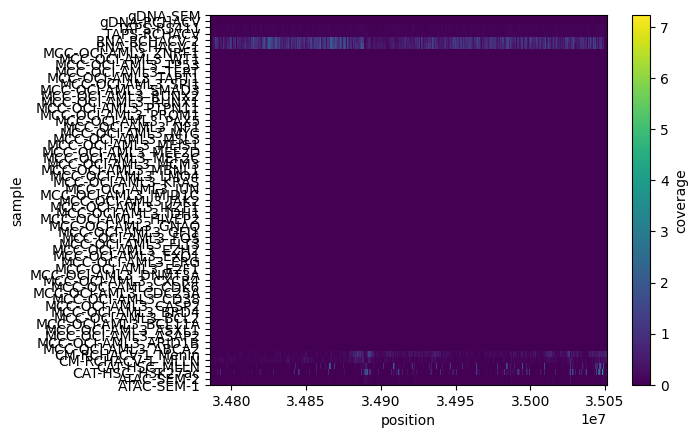

In [18]:
cpm.plot()

/Users/catherine/work/software/QuantNado/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/catherine/work/software/QuantNado/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


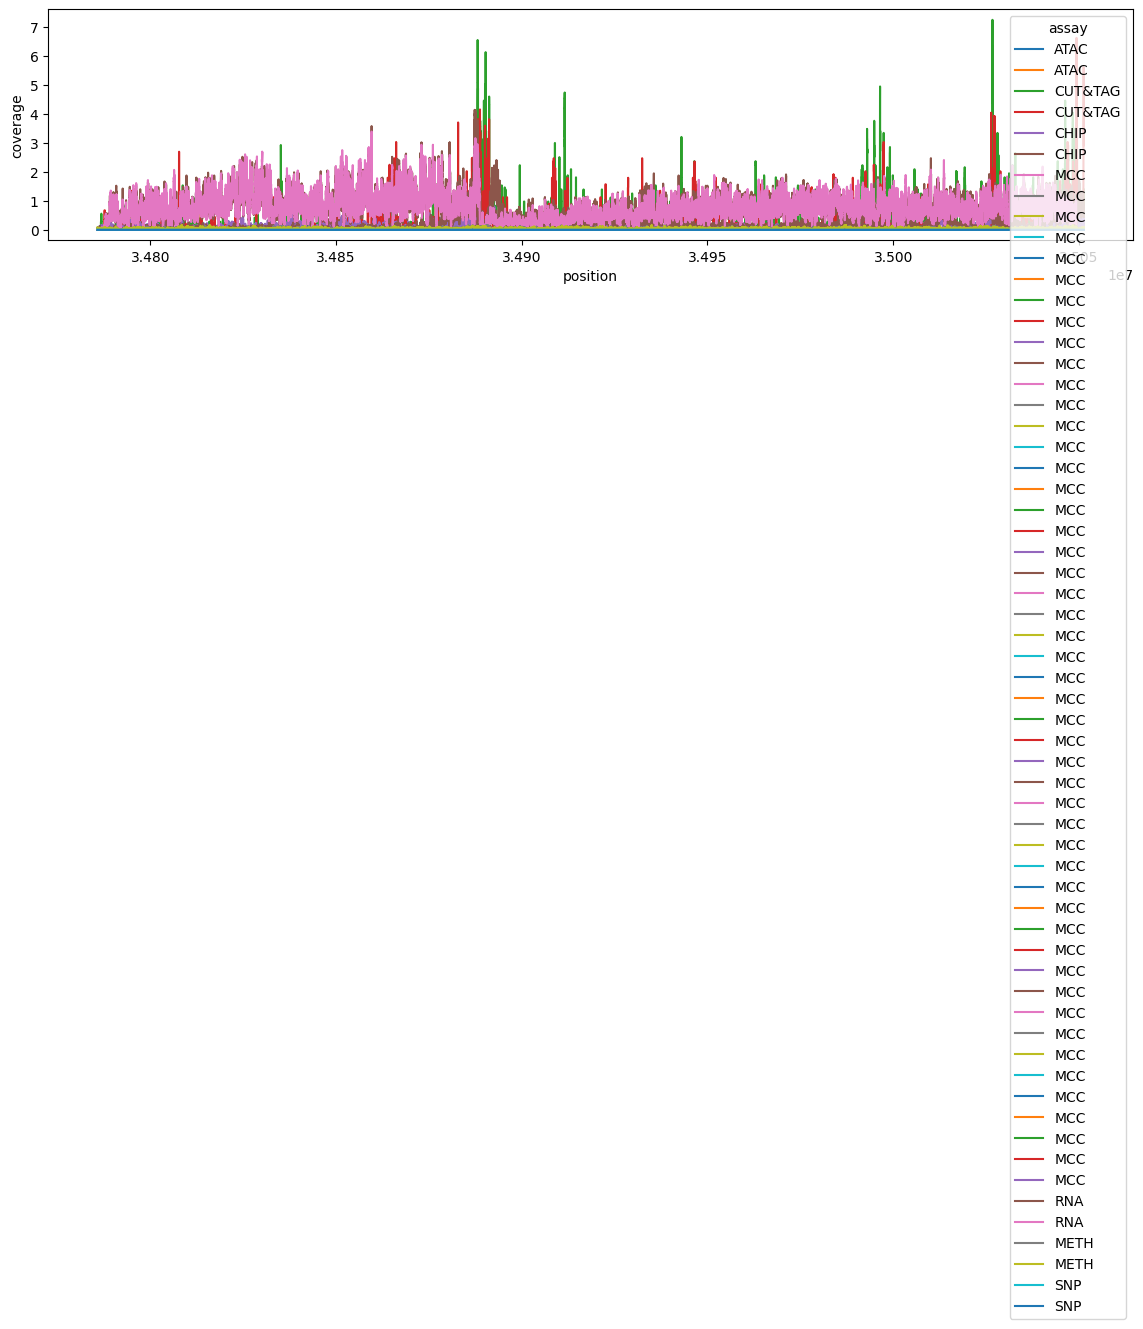

In [19]:
# Plot both samples in the region
cpm.plot.line(x="position", hue="assay", figsize=(14, 3))

### Annotation

In [20]:
qn.set_annotation(GTF_FILE)

info = qn.gene_info("GNAQ")
print(info)

2026-04-10 17:22:11.001 | INFO     | quantnado.analysis.core:set_annotation:267 - Loaded annotation: 78,691 genes from local/gencode.v49.annotation.gtf


{'gene_name': 'GNAQ', 'gene_id': 'ENSG00000156052.12', 'chrom': 'chr9', 'start': 77716097, 'end': 78031972, 'strand': '-', 'locus': 'chr9:77716097-78031972', 'exons': [{'start': 77716097, 'end': 77721513, 'exon_number': None}, {'start': 77719117, 'end': 77721513, 'exon_number': None}, {'start': 77719658, 'end': 77721513, 'exon_number': None}, {'start': 77728514, 'end': 77728667, 'exon_number': None}, {'start': 77728514, 'end': 77728667, 'exon_number': None}, {'start': 77728514, 'end': 77728667, 'exon_number': None}, {'start': 77794463, 'end': 77794592, 'exon_number': None}, {'start': 77794463, 'end': 77794592, 'exon_number': None}, {'start': 77794463, 'end': 77794592, 'exon_number': None}, {'start': 77797520, 'end': 77797648, 'exon_number': None}, {'start': 77797520, 'end': 77797648, 'exon_number': None}, {'start': 77797520, 'end': 77797648, 'exon_number': None}, {'start': 77797528, 'end': 77797648, 'exon_number': None}, {'start': 77815616, 'end': 77815770, 'exon_number': None}, {'star

In [21]:
print(qn.sel_gene("GNAQ", padding=5_000, assay="MCC"))

<xarray.Dataset> Size: 6GB
Dimensions:           (sample: 49, position: 325876)
Coordinates:
  * sample            (sample) <U19 4kB 'MCC-OCI-AML3_ABCA2' ... 'MCC-OCI-AML...
    assay             (sample) <U7 1kB 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
  * position          (position) int64 3MB 77711097 77711098 ... 78036972
Data variables: (12/50)
    coverage          (sample, position) float32 64MB dask.array<chunksize=(1, 325876), meta=np.ndarray>
    viewpoint_ABCA2   (sample, position) float64 128MB dask.array<chunksize=(1, 325876), meta=np.ndarray>
    viewpoint_ARID1B  (sample, position) float64 128MB dask.array<chunksize=(1, 325876), meta=np.ndarray>
    viewpoint_ASAP2   (sample, position) float64 128MB dask.array<chunksize=(1, 325876), meta=np.ndarray>
    viewpoint_ASXL1   (sample, position) float64 128MB dask.array<chunksize=(1, 325876), meta=np.ndarray>
    viewpoint_BCL11A  (sample, position) float64 128MB dask.array<chunksize=(1, 325876), meta=np.ndarray>
    ...       

In [22]:
region = qn.sel_gene("GNAQ", padding=5_000, assay="ATAC")
print("Exons:", region.attrs["exons"])   # list of 1-based exon intervals
print("Locus:", region.attrs["locus"])   # "chr9:77413765-78344335" (with padding)

Exons: [{'start': 77716097, 'end': 77721513, 'exon_number': None}, {'start': 77719117, 'end': 77721513, 'exon_number': None}, {'start': 77719658, 'end': 77721513, 'exon_number': None}, {'start': 77728514, 'end': 77728667, 'exon_number': None}, {'start': 77728514, 'end': 77728667, 'exon_number': None}, {'start': 77728514, 'end': 77728667, 'exon_number': None}, {'start': 77794463, 'end': 77794592, 'exon_number': None}, {'start': 77794463, 'end': 77794592, 'exon_number': None}, {'start': 77794463, 'end': 77794592, 'exon_number': None}, {'start': 77797520, 'end': 77797648, 'exon_number': None}, {'start': 77797520, 'end': 77797648, 'exon_number': None}, {'start': 77797520, 'end': 77797648, 'exon_number': None}, {'start': 77797528, 'end': 77797648, 'exon_number': None}, {'start': 77815616, 'end': 77815770, 'exon_number': None}, {'start': 77815616, 'end': 77815770, 'exon_number': None}, {'start': 77815616, 'end': 77815770, 'exon_number': None}, {'start': 77815616, 'end': 77815770, 'exon_numbe

### Locus plot

Genome-browser style multi-track view. One track per sample, modality-aware rendering:
`coverage` → filled area, `stranded_coverage` → mirrored strands, `methylation` → scatter at CpG sites, `variant` → lollipop AF.

In [23]:
# Check what's there
print(list(region.data_vars))

['atac', 'coverage']


In [24]:
region.sample

<xarray.DataArray 'sample' (sample: 2)> Size: 152B
array(['ATAC-SEM-1', 'ATAC-SEM-2'], dtype='<U19')
Coordinates:
  * sample   (sample) <U19 152B 'ATAC-SEM-1' 'ATAC-SEM-2'
    assay    (sample) <U7 56B 'ATAC' 'ATAC'

In [ ]:
from quantnado.analysis.plot import locus_plot

region = qn.sel_gene("GNAQ", padding=1_000, assay=["ATAC", "CHIP", "CAT", "METH", "SNP"])
modalities = ["coverage"] * 55 + ["stranded_coverage"] * 2 + ["methylation"] * 2 + ["variant"] * 2
locus_plot(
    locus=region.attrs["locus"],
    sample_names=region.sample.values,
    modality=modalities,
    coverage=region["coverage"],
    coverage_fwd=region["rna_fwd"],
    coverage_rev=region["rna_rev"],
    methylation=region["methyl_pct"],
    allele_freq=region["AF"],
    genotype=region["GT"],
    figsize=(14, 10),
)

AttributeError: 'list' object has no attribute 'upper'

### Windowed signal matrix

Summarise signal in non-overlapping windows across chr21 — useful as input to `heatmap`, `correlate`, and `pca`.

In [26]:
# 50 × 100 kb windows across chr21 starting at 5 Mb
window_size = 100_000
n_windows = 50
starts = [5_000_000 + i * window_size for i in range(n_windows)]

atac_samples = ["ATAC-SEM-1", "ATAC-SEM-2"]

rows = []
for start in starts:
    r = qn.sel(chrom="chr21", start=start, end=start + window_size)
    row = r["coverage"].sel(sample=atac_samples).sum("position").values
    rows.append(row)

signal_df = pd.DataFrame(rows, columns=atac_samples, index=[f"chr21:{s // 1000}k" for s in starts])
signal_df.head()

,ATAC-SEM-1,ATAC-SEM-2
chr21:5000k,4268.0,3057.0
chr21:5100k,18053.0,19319.0
chr21:5200k,62172.0,55428.0
chr21:5300k,20362.0,16915.0
chr21:5400k,75.0,0.0


### Heatmap

Clustered heatmap of signal across genomic windows × samples. Works on `reduce()` output, `count_features()` output, or any `pd.DataFrame` (rows = features, columns = samples).

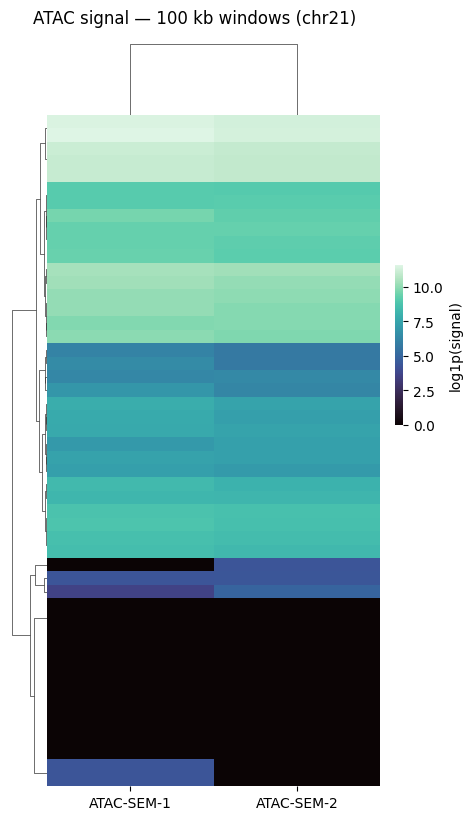

In [27]:
from quantnado.analysis.plot import heatmap

heatmap(signal_df, log_transform=True, title="ATAC signal — 100 kb windows (chr21)", figsize=(4, 8))

### Sample–sample correlation

In [28]:
region = qn.sel_gene("GNAQ", assay="MCC", padding=5_000)
region_df = region.to_dataframe()
region_df.head()

coverage  viewpoint_ABCA2  viewpoint_ARID1B  \
sample             position                                                
MCC-OCI-AML3_ABCA2 77711097       0.0              0.0               NaN   
                   77711098       0.0              0.0               NaN   
                   77711099       0.0              0.0               NaN   
                   77711100       0.0              0.0               NaN   
                   77711101       0.0              0.0               NaN   

                             viewpoint_ASAP2  viewpoint_ASXL1  \
sample             position                                     
MCC-OCI-AML3_ABCA2 77711097              NaN              NaN   
                   77711098              NaN              NaN   
                   77711099              NaN              NaN   
                   77711100              NaN              NaN   
                   77711101              NaN              NaN   

                             viewpoint_BCL11A  viewpoint_BCL2  viewpoint_BRD4  \
sample             position                                                     
MCC-OCI-AML3_ABCA2 77711097               NaN             NaN             NaN   
                   77711098               NaN             NaN             NaN   
                   77711099               NaN             NaN             NaN   
                   77711100               NaN             NaN             NaN   
                   77711101               NaN             NaN             NaN   

                             viewpoint_CASP2  viewpoint_CD38  ...  \
sample             position                                   ...   
MCC-OCI-AML3_ABCA2 77711097              NaN             NaN  ...   
                   77711098              NaN             NaN  ...   
                   77711099              NaN             NaN  ...   
                   77711100              NaN             NaN  ...   
                   77711101              NaN             NaN  ...   

                             viewpoint_RUNX1  viewpoint_RUNX2  \
sample             position                                     
MCC-OCI-AML3_ABCA2 77711097              NaN              NaN   
                   77711098              NaN              NaN   
                   77711099              NaN              NaN   
                   77711100              NaN              NaN   
                   77711101              NaN              NaN   

                             viewpoint_SMAD3  viewpoint_SPI1  viewpoint_TAPT1  \
sample             position                                                     
MCC-OCI-AML3_ABCA2 77711097              NaN             NaN              NaN   
                   77711098              NaN             NaN              NaN   
                   77711099              NaN             NaN              NaN   
                   77711100              NaN             NaN              NaN   
                   77711101              NaN             NaN              NaN   

                             viewpoint_TERT  viewpoint_TP53  viewpoint_WT1  \
sample             position                                                  
MCC-OCI-AML3_ABCA2 77711097             NaN             NaN            NaN   
                   77711098             NaN             NaN            NaN   
                   77711099             NaN             NaN            NaN   
                   77711100             NaN             NaN            NaN   
                   77711101             NaN             NaN            NaN   

                             viewpoint_ZNRF1  assay  
sample             position                          
MCC-OCI-AML3_ABCA2 77711097              NaN    MCC  
                   77711098              NaN    MCC  
                   77711099              NaN    MCC  
                   77711100              NaN    MCC  
                   77711101              NaN    MCC  

[5 rows x 51 columns]

In [29]:
region_df.describe()

,coverage,viewpoint_ABCA2,viewpoint_ARID1B,viewpoint_ASAP2,viewpoint_ASXL1,viewpoint_BCL11A,viewpoint_BCL2,viewpoint_BRD4,viewpoint_CASP2,viewpoint_CD38,...,viewpoint_PTPN11,viewpoint_RUNX1,viewpoint_RUNX2,viewpoint_SMAD3,viewpoint_SPI1,viewpoint_TAPT1,viewpoint_TERT,viewpoint_TP53,viewpoint_WT1,viewpoint_ZNRF1
count,15967924.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,...,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0,325876.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
from quantnado.analysis.plot import correlate

corr_df, g = correlate(region["coverage"], log_transform=True, title="GNAQ region correlation")
corr_df

ValueError: Too few samples with variable signal to compute a correlation matrix (got 0 after filtering constant/empty columns). Check that your data has coverage across the requested regions.

### PCA

`run_pca` takes a 2D `xr.DataArray` with a `sample` dimension. Here we use all 49 MCC viewpoints as samples, treating genomic positions as features — each viewpoint is a distinct chromatin contact profile.

In [ ]:
import xarray as xr

from quantnado.analysis.pca import plot_pca_scatter, plot_pca_scree, run_pca

# Get a large chr21 region covering all MCC viewpoint neighbourhoods
mcc_region = qn.sel(chrom="chr21", start=1_000_000, end=46_000_000)

# Stack all MCC viewpoint arrays into a single (n_viewpoints, n_positions) DataArray
mcc_keys = sorted(k for k in mcc_region.data_vars if k.startswith("mcc_"))
mcc_da = xr.concat([mcc_region[k] for k in mcc_keys], dim="sample")  # (49, n_pos)

print(f"Shape: {mcc_da.sizes}")
mcc_da

In [ ]:
pca_obj, pca_result = mcc_da.run_pca(
    n_components=5,
    nan_handling_strategy="set_to_zero",
    subset_size=50_000,  # subsample positions for speed
    subset_strategy="random",
    random_state=42,
)
pca_result

In [ ]:
plot_pca_scree(pca_obj)

In [ ]:
# Build a metadata DataFrame with viewpoint names as labels
viewpoint_names = [k[len("mcc_") :] for k in mcc_keys]
mcc_meta = pd.DataFrame(
    {
        "sample_id": [f"MCC-OCI-AML3_{vp}" for vp in viewpoint_names],
        "viewpoint": viewpoint_names,
    }
)

plot_pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=mcc_meta,
    colour_by=None,
    sample_column="sample_id",
)

### metaplot / tornadoplot

Require `qn.extract()` — anchors signal around genomic features from a GTF file, returning a `(interval, bin, sample)` DataArray.

In [ ]:
binned = qn.extract(
    feature_type="promoter",
    GTF_FILE=GTF_FILE,
    fixed_width=2000,
    anchor="start",
    bin_size=50,
    assay="atac",
)

# CPM-normalise first
binned_cpm = normalise(binned, qn, method="cpm")

# Metaplot: average signal profile across all intervals
binned_cpm.metaplot(
    binned_cpm,
    modality="coverage",
    groups={"SEM": ["ATAC-SEM-1", "ATAC-SEM-2"]},
    title="ATAC signal at promoters",
)

# Tornadoplot: heatmap with one row per interval, sorted by signal strength
binned_cpm.tornadoplot(
    binned_cpm,
    modality="coverage",
    samples=["ATAC-SEM-1", "ATAC-SEM-2"],
    title="ATAC signal at promoters",
)

### Feature counts (DESeq2-compatible)

Count signal over genes/exons from a GTF file. Returns a `(genes × samples)` integer count matrix.

In [ ]:
# Count RNA signal over gene bodies
counts, features = qn.count_features(
    assay="RNA",
    gtf_file=GTF_FILE,
    feature_type="transcript",
)
# counts: pd.DataFrame — rows=genes, columns=samples (integer counts)
# features: pd.DataFrame — gene metadata (chrom, start, end, length)

# Normalise to CPM
cpm = normalise(counts, qn, method="cpm", feature_lengths=features["range_length"])

# Heatmap of top variable genes
heatmap(cpm, log_transform=True, title="Gene-level RNA signal")